In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] =  'YOUR_TOKEN_HERE'

!pip install -q kaggle
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d /content/lgg-data
print("✅ Dataset ready")

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:39<00:00, 18.8MB/s]

✅ Dataset ready


In [14]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — Imports and data loading
# ══════════════════════════════════════════════════════════════════
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

BASE_DIR = '/content/lgg-data/kaggle_3m/'

def load_data(base_dir, img_size=(128, 128)):
    images, masks = [], []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.endswith('.tif') and '_mask' not in f:   # image files only
                img_path  = os.path.join(root, f)
                mask_path = img_path.replace('.tif', '_mask.tif')
                if not os.path.exists(mask_path):
                    continue
                img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if img is None or mask is None:
                    continue
                images.append(cv2.resize(img,  img_size))
                masks.append(cv2.resize(mask, img_size))
    images = np.array(images).reshape(-1, img_size[0], img_size[1], 1)
    masks  = np.array(masks).reshape(-1, img_size[0], img_size[1], 1)
    return images, masks

images, masks = load_data(BASE_DIR)
images = images / 255.0
masks  = (masks / 255.0 > 0.5).astype(np.float32)   # clean binary masks

# sanity check — this dataset is mostly tumor-free slices
n_tumor = (masks.reshape(len(masks), -1).sum(1) > 0).sum()
print(f'Images: {images.shape}, Masks: {masks.shape}')
print(f'Slices with a tumor: {n_tumor} / {len(masks)} ({100*n_tumor/len(masks):.1f}%)')

Images: (3929, 128, 128, 1), Masks: (3929, 128, 128, 1)
Slices with a tumor: 1373 / 3929 (34.9%)


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — U-Net model (complete)
# ══════════════════════════════════════════════════════════════════
from tensorflow.keras.optimizers import Adam

def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = K.mean(K.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def unet_model(input_size=(128, 128, 1)):
    inputs = layers.Input(input_size)
    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)
    # Bottleneck
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    # Decoder
    u2 = layers.UpSampling2D(2)(c3)
    u2 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)
    u2 = layers.Concatenate()([u2, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)
    u1 = layers.UpSampling2D(2)(c4)
    u1 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    u1 = layers.Concatenate()([u1, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)
    return models.Model(inputs, outputs)

model = unet_model()
model.compile(optimizer=Adam(1e-4), loss=bce_dice_loss,
              metrics=['accuracy', dice_coef])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     73,792 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_9[0][0], 

 Total params: 2,066,497 (7.88 MB)

 Trainable params: 2,066,497 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

Training on 1373 tumor-containing slices
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 64s 574ms/step - accuracy: 0.9580 - dice_coef: 0.0820 - loss: 1.2015 - val_accuracy: 0.9703 - val_dice_coef: 0.1768 - val_loss: 0.9281
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.9624 - dice_coef: 0.2153 - loss: 0.8903 - val_accuracy: 0.9520 - val_dice_coef: 0.2276 - val_loss: 0.8873
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9610 - dice_coef: 0.2498 - loss: 0.8582 - val_accuracy: 0.9274 - val_dice_coef: 0.2614 - val_loss: 0.8885
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9613 - dice_coef: 0.3016 - loss: 0.8178 - val_accuracy: 0.9695 - val_dice_coef: 0.3697 - val_loss: 0.7367
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9642 - dice_coef: 0.3397 - loss: 0.7789 - val_accuracy: 0.9531 - val_dice_coef: 0.3545 - val_loss: 0.7811
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.9655 - dice_coef: 0.3548 - 

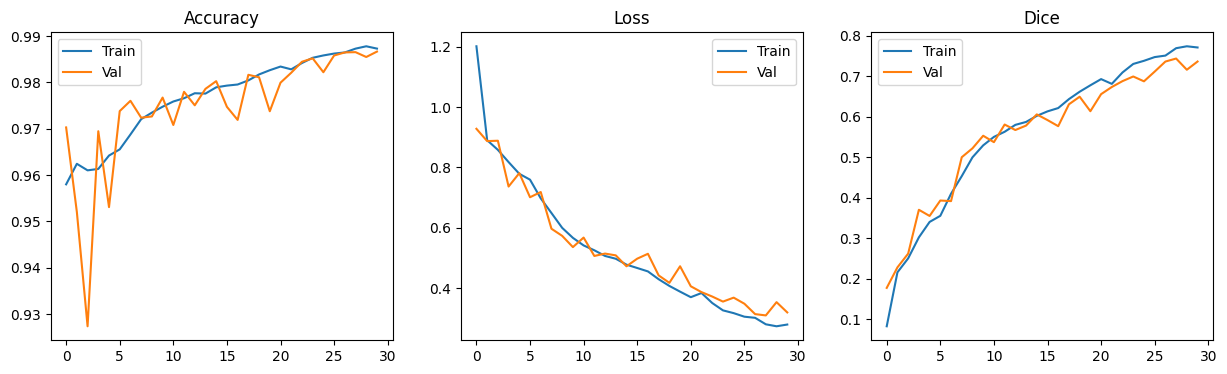

In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — Train on tumor-containing slices
# ══════════════════════════════════════════════════════════════════
tumor_mask = masks.reshape(len(masks), -1).sum(1) > 0
img_t = images[tumor_mask]
msk_t = masks[tumor_mask]
print(f'Training on {len(img_t)} tumor-containing slices')

Xtr, Xte, ytr, yte = train_test_split(img_t, msk_t, test_size=0.2, random_state=42)

history = model.fit(Xtr, ytr, validation_split=0.1, epochs=30, batch_size=16)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title('Accuracy')
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title('Loss')
plt.subplot(1, 3, 3)
plt.plot(history.history['dice_coef'], label='Train')
plt.plot(history.history['val_dice_coef'], label='Val')
plt.legend(); plt.title('Dice')
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 841ms/step - accuracy: 0.9867 - dice_coef: 0.7481 - loss: 0.3120
Test accuracy: 0.9867 | Dice: 0.7481
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step


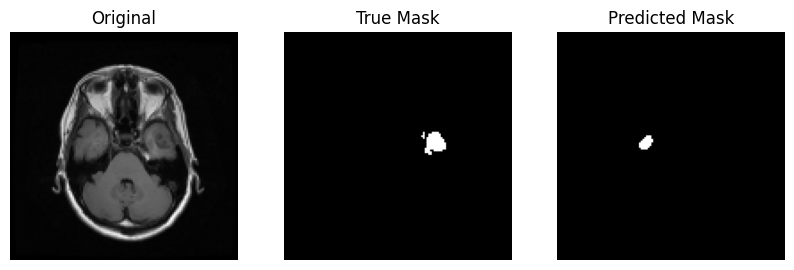

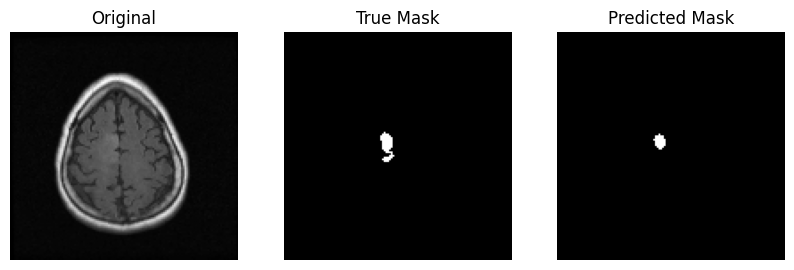

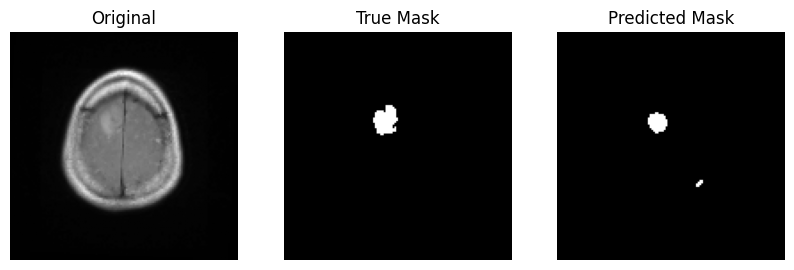

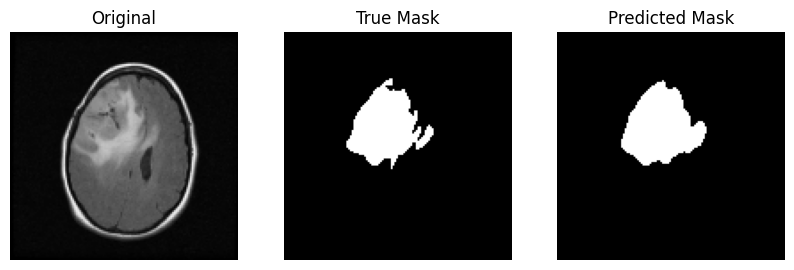

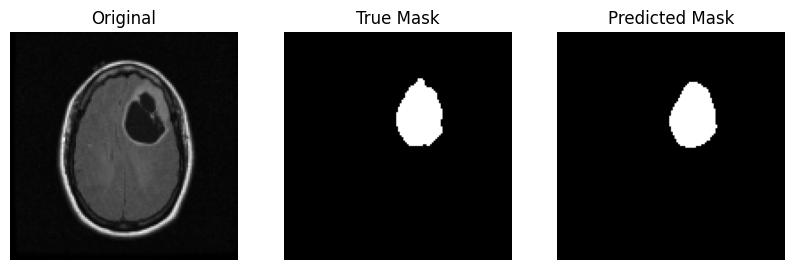

In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — Evaluate + visualize
# ══════════════════════════════════════════════════════════════════
test_loss, test_acc, test_dice = model.evaluate(Xte, yte)
print(f'Test accuracy: {test_acc:.4f} | Dice: {test_dice:.4f}')

predictions = (model.predict(Xte) > 0.5).astype(np.uint8)

for i in range(5):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(Xte[i].reshape(128, 128), cmap='gray')
    plt.title("Original"); plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(yte[i].reshape(128, 128), cmap='gray')
    plt.title("True Mask"); plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i].reshape(128, 128), cmap='gray')
    plt.title("Predicted Mask"); plt.axis('off')
    plt.show()

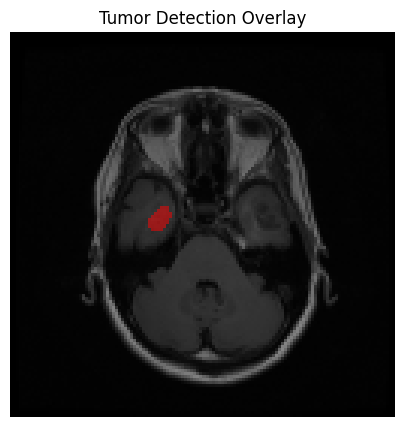

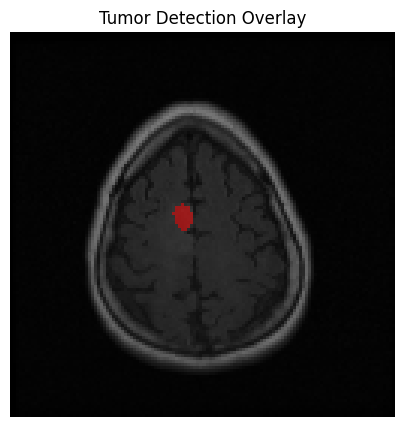

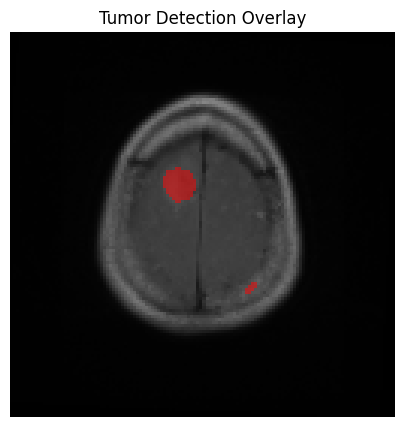

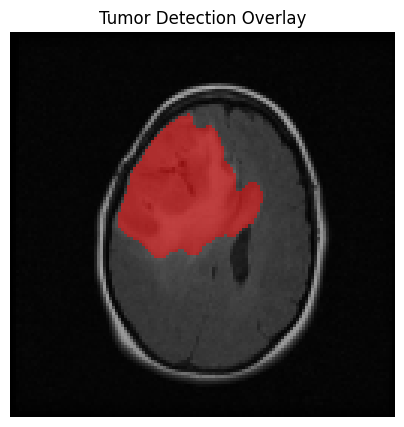

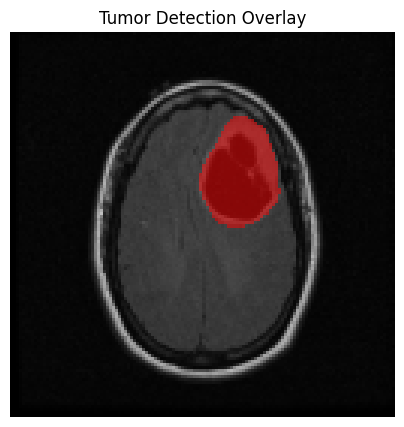

In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — Tumor overlay
# ══════════════════════════════════════════════════════════════════
def overlay_mask(image, mask, alpha=0.5):
    img_rgb = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]   # red for tumor region
    return cv2.addWeighted(img_rgb, 1 - alpha, overlay, alpha, 0)

for i in range(5):
    img  = Xte[i].reshape(128, 128)
    mask = predictions[i].reshape(128, 128)
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay_mask(img, mask))
    plt.title("Tumor Detection Overlay"); plt.axis('off')
    plt.show()